# User study: counterfactual reasoning by explanation property, simulated with Sim2Real

Same four phases as the other two notebooks, but with no AI model to train in
Phase 2.

Sim2Real simulates from a fixed published corpus: the stimuli, the attribution
vectors participants saw, the AI's predictions and the ground-truth answer key
are all in `assets/`. `prepare_dataset(dataset_id="sim2real")` loads that
corpus -- its train/test split is the corpus's own `training`/`test` labels,
not a fresh `train_test_split` -- but there is still no AI model to train:
`run_sim2real_study` reads `study.data` for its instance ids, but never
`study.trained_ai_model`.

The study asks how accurately people answer a **counterfactual** question ("if
this feature changed, would the prediction go up or down?") under four
**explanation properties**: `faithful`, `sparse`, `robust` and `sparse_robust`.

### Note on naming

These four are `xai_property` values, not `xai_type`. They describe a quality of
the explanation, not which family it belongs to, and `xai_property` is also the
signal that tells a Sim2Real design apart from a plain CoAX one. Using the wrong
key here routes the study to the wrong model.

## Phase 0: Set up your environment

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Walk up until the repo root (the directory holding `src/`) is found, so the
# notebook runs from anywhere inside the checkout.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src").is_dir():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import src as xk

# Used by the human-vs-model comparison step in Phase 4.
import base64
from IPython.display import Image
from server import pipeline

OUTPUT_DIR = REPO_ROOT / "tutorials" / "sim2real_workflow_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root :", REPO_ROOT)
print("output dir:", OUTPUT_DIR)

ModuleNotFoundError: No module named 'src.api'

## Phase 1: Configure the User Study

### Step 1.1 Initialize the study workflow

**Goal:**

Instantiate the study object.

**Instruction:**

Create a study workflow instance with a project name and `OUTPUT_DIR`.

<details>
<summary>Hint</summary>

Call

```python
xk.xaikitTest(project_name: str, output_dir: str | Path)
```

</details>

In [ ]:
# YOUR CODE HERE
# xaikitTest = ?

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

xaikitTest = xk.xaikitTest("sim2real_counterfactual_study", output_dir=OUTPUT_DIR)
xaikitTest

<details>
<summary>Click here to see the correct code</summary>

```python
xaikitTest = xk.xaikitTest("sim2real_counterfactual_study", output_dir=OUTPUT_DIR)
xaikitTest
```

</details>

### Step 1.2 Define the user study variables

**Goal:**

Register the study's variables and validate the design.

**Instruction:**

*   `xai_property` -- the explanation property. Between-subjects: each
    simulated participant is assigned to one condition, levels `faithful`,
    `sparse`, `robust`, `sparse_robust`.
*   `user_task` -- a control variable fixed at `counterfactual_simulation`.
    Sim2Real answers a counterfactual question, not a forward-prediction one.
*   `counterfactual_accuracy` -- the dependent variable, `continuous`. It is
    whether the model's "higher or lower" answer matches the published key.

<details>
<summary>Hint</summary>

*   Same shape as the other two notebooks: build `iv_config`, `cvs` and `dvs`,
    then `xaikitTest.set_design(...)` and `xaikitTest.validate(stage="design", ...)`.
*   Use the key `"xai_property"`, not `"xai_type"`.

</details>

In [ ]:
# YOUR CODE HERE

XAI_PROPERTIES = []

## Construct IVs, DVs, CVs
iv_config = {}

cvs = {}

dvs = {}

## Register

## Validate

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

XAI_PROPERTIES = ["faithful", "sparse", "robust", "sparse_robust"]

iv_config = {
    "xai_property": {
        "type": "between",
        "levels": XAI_PROPERTIES,
    },
}

cvs = {"user_task": ["counterfactual_simulation"]}

dvs = {"counterfactual_accuracy": ["continuous"]}

xaikitTest.set_design(iv_config=iv_config, cvs=cvs, dvs=dvs, show=True)


IV configuration:
  xai_property         type=between  randomization=-     levels=['faithful', 'sparse', 'robust', 'sparse_robust']

CVs: ['user_task']
DVs: ['counterfactual_accuracy']


<details>
<summary>Click here to see the correct code</summary>

```python
XAI_PROPERTIES = ["faithful", "sparse", "robust", "sparse_robust"]

iv_config = {
    "xai_property": {
        "type": "between",
        "levels": XAI_PROPERTIES,
    },
}

cvs = {"user_task": ["counterfactual_simulation"]}

dvs = {"counterfactual_accuracy": ["continuous"]}

xaikitTest.set_design(iv_config=iv_config, cvs=cvs, dvs=dvs, show=True)
xaikitTest.validate(stage="design", strict=False, show=True)
```

</details>

### Step 1.3 Configure the dataset

`prepare_dataset(dataset_id="sim2real")` loads the published corpus directly
from `assets/ai_dataset/sim2real/` (raw feature values) and
`assets/explanations/xai_desiderata/` (attributions, counterfactuals, the
answer key), and returns it as a normal `PreparedDataset` -- `test_size`/
`random_state`/`feature_cols` don't apply and are silently ignored, since the
split is the corpus's own published `training`/`test` labels, not a fresh
`train_test_split`. What's actually skipped is Phase 2's AI model training,
further down -- Sim2Real's AI predictions are already in the corpus too.

Run the cell below to see what the corpus actually offers.

In [ ]:
data = xaikitTest.prepare_dataset(dataset_id="sim2real")

train_instance_ids = data.split.train_instance_ids.tolist()
test_instance_ids = data.split.test_instance_ids.tolist()
print(f"published training instances: {len(train_instance_ids)} -- {train_instance_ids}")
print(f"published test instances: {len(test_instance_ids)}")
print("first few test:", test_instance_ids[:10])

Available training datasets: ['sim2real (published corpus)']


Dataset   : sim2real  (39 rows, 67 model features)
Features  : ['age', 'capital-gain', 'capital-loss', 'education', 'hours-per-week', 'marital', 'native-country', 'occupation', 'race', 'relationship', 'sex', 'workclass']
Encoding  : one-hot
Train set : 10 samples  (26%)
Test set  : 29 samples  (74%)
Class balance (train) -> class 0: 5
Class balance (train) -> class 1: 5
First test instanceIds: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
published training instances: 10 -- [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
published test instances: 29
first few test: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


### Step 1.4 Build the trial table

**Goal:**

Build the trials with `generate_trials()`, the same call the other two
tutorials use -- not a hand-rolled loop.

**Instruction:**

`generate_trials()` samples from the `PreparedDataset` Step 1.3 just built,
same as any other dataset. No `allowed_instance_ids`/manual instance list
needed here: that dataset's own `train_instance_ids`/`test_instance_ids` --
read straight off `data.split` in Step 1.3 -- already *are* the published
corpus's `training`/`test` ids, so a plain `generate_trials()` call
reproduces exactly the instances the published study and the fitted model
were calibrated against.

`xai_property` being a between-subjects IV is what makes
`participants_per_between_condition` assign each participant to exactly one
condition. Set `num_training`/`num_testing` to the full size of each
published split so every participant sees every instance.

<details>
<summary>Hint</summary>

```python
xaikitTest.generate_trials(
    participants_per_between_condition=N_PARTICIPANTS_PER_CONDITION,
    num_training=len(train_instance_ids),
    num_testing=len(test_instance_ids),
    output_dir="trials",
    show=True,
)
```

*   `xaikitTest.trials` afterwards is a list of dicts, not a DataFrame --
    wrap it in `pd.DataFrame(...)` to inspect it, the same as the general
    workflow tutorial does.

</details>

In [ ]:
# YOUR CODE HERE

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

N_PARTICIPANTS_PER_CONDITION = 12

trial_result = xaikitTest.generate_trials(
    participants_per_between_condition=N_PARTICIPANTS_PER_CONDITION,
    num_training=len(train_instance_ids),
    num_testing=len(test_instance_ids),
    output_dir="trials",
    show=True,
)

trials_preview = pd.DataFrame(xaikitTest.trials)
print(f"trials: {len(trials_preview)} rows, "
      f"{trials_preview['participantId'].nunique()} participants")
trials_preview.head()

Counterbalancing strategy: complete_counterbalancing
Participant assignments: 48 total
Instance pool rows: 29
Trial rows: 1872
Exported trial artifacts:
  CSV     : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_workflow_output/trials/trials.csv
  JSON    : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_workflow_output/trials/trials.json
  Summary : /Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_workflow_output/trials/design_summary.json

Previewing first 10 trial rows:
{'participantId': 1, 'trialId': 1, 'phase': 'training', 'phaseTrialId': 1, 'block': 1, 'trialWithinBlock': 1, 'withinCondition': 'single_condition', 'xai_property': 'faithful', 'dataId': 'sim2real', 'instanceId': '7'}
{'participantId': 1, 'trialId': 2, 'phase': 'training', 'phaseTrialId': 2, 'block': 1, 'trialWithinBlock': 2, 'withinCondition': 'single_condition', 'xai_property': 'faithful', 'dataId': 'sim2real', 'instanceId': '3'}
{'par

,participantId,trialId,block,trialWithinBlock,withinCondition,xai_property,dataId,instanceId,CV_user_task_levels,phase,phaseTrialId
0,1,1,1,1,single_condition,faithful,sim2real,7,counterfactual_simulation,training,1
1,1,2,1,2,single_condition,faithful,sim2real,3,counterfactual_simulation,training,2
2,1,3,1,3,single_condition,faithful,sim2real,2,counterfactual_simulation,training,3
3,1,4,1,4,single_condition,faithful,sim2real,8,counterfactual_simulation,training,4
4,1,5,1,5,single_condition,faithful,sim2real,5,counterfactual_simulation,training,5


<details>
<summary>Click here to see the correct code</summary>

```python
N_PARTICIPANTS_PER_CONDITION = 12

trial_result = xaikitTest.generate_trials(
    participants_per_between_condition=N_PARTICIPANTS_PER_CONDITION,
    num_training=len(train_instance_ids),
    num_testing=len(test_instance_ids),
    output_dir="trials",
    show=True,
)

trials_preview = pd.DataFrame(xaikitTest.trials)
print(f"trials: {len(trials_preview)} rows, "
      f"{trials_preview['participantId'].nunique()} participants")
trials_preview.head()
```

</details>

## Phase 2: Prepare the AI Model and its Explanations -- no AI model to train

There is no `train_AI_model()` call: the AI's predictions are already in the
published corpus, not something this notebook fits. The explanations are
published too, not generated -- but unlike the AI model there is still
something to do with them, below.

This is the phase that separates Sim2Real from the other two notebooks. In the
general and CoXAM tutorials, Phase 2 is where the thing being explained gets
built. Here it was built once, offline, and shipped -- Step 2.1 just loads and
looks at it.

### Step 2.1 Visualize a published explanation

Nothing was generated, but the published explanation can still be inspected.
Project one trial into the study's 12 raw features (`Sim2RealAttributionProjector`
already reduces the 67 encoded dimensions down to these -- the same corpus
`sim2real_projector` from Step 1.3, reused rather than reloaded) and plot it
the way the apparatus showed it to participants: a centre-anchored bar per
feature, blue toward "above $50,000", red toward "below", with the changed
feature -- the counterfactual manipulation the participant reasoned about --
highlighted.

In [ ]:
from src.xai_adapter import plot_sim2real_explanation
from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_trial_executor import (
    build_sim2real_projector,
)

# Step 1.3's PreparedDataset carries one fixed encoded vector per instance,
# not a per-xai_property attribution -- inspecting a specific explanation
# needs the projector itself.
sim2real_projector = build_sim2real_projector()

example_instance_id = test_instance_ids[0]
example_property = "robust"

example_pair = sim2real_projector.project(
    example_instance_id,
    exp_property=example_property,
    normalize_by_i_max=True,
)
fig, axes = plot_sim2real_explanation(
    example_pair,
    title=f"Published explanation — instance {example_instance_id}, {example_property}",
)

ImportError: cannot import name 'plot_sim2real_explanation' from 'src.xai_adapter' (/Users/wangzhuoyulucas/Documents/GitHub/xaik-tool-cognitive-agent/src/xai_adapter/__init__.py)

## Phase 3: Run the User Study Simulation

### Step 3.1 Inspect how each condition is simulated

Sim2Real does not simulate all four conditions the same way, and it is worth
seeing that before running rather than discovering it in the results.

Under the default `strategy="auto"`, each condition uses the strategy that was
found to match real human behaviour for it, plus a response-level lapse rate
where one is needed. Run the cell below to print the current configuration.

In [ ]:
from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_trial_executor import (
    sim2real_lapse_for,
    sim2real_strategy_for,
)

print(f"{'condition':<16}{'strategy':<22}{'response lapse'}")
for xai_property in XAI_PROPERTIES:
    print(f"{xai_property:<16}{sim2real_strategy_for(xai_property):<22}"
          f"{sim2real_lapse_for(xai_property)}")

condition       strategy              response lapse
faithful        attribution_sum       0.0
sparse          sensitive_features    0.0
robust          attribution_sum       0.176
sparse_robust   sensitive_features    0.0


Two things to read out of that table:

*   **`sparse` and `sparse_robust` use a different strategy.** `attribution_sum`
    reads the explanation's attributions, which requires the changed feature to
    have a visible attribution -- true on 6.9% of `sparse` trials. With nothing
    to read it answers "no increase" every time, a constant predictor. Those two
    conditions fall back to exemplar similarity over feature values instead.
*   **`robust` carries a response lapse.** Its changed feature is visible on
    every trial, so the evidence is never ambiguous and the model would be right
    every single time -- 1.000 against a real human 0.912. The lapse is the
    standard psychometric slip on easy trials, applied to the response.

### Step 3.2 Register Sim2Real and run the simulation

**Goal:**

Run every simulated participant through every trial with Sim2Real.

**Instruction:**

*   Register Sim2Real as the cognitive model by id.
*   Run the whole experiment through `run_sim2real_study`, storing the results
    back on the study object.
*   Take the defaults: no `strategy` and no `cognitive_params`. Passing either
    one **overrides the per-condition configuration you just printed** and
    forces a single model across all four conditions -- which is occasionally
    what you want for a comparison, and never what you want by default.

`xaikitTest.run_experiment(...)` would also work now that Step 1.3 prepared a
dataset -- it dispatches to the same `run_sim2real_study` internally. This
notebook calls it directly instead, since Step 3.2 is the one place worth
seeing the runner it actually is.

<details>
<summary>Hint</summary>

*   `xaikitTest.set_cognitive_model(cognitive_model_id="sim2real")`
*   `from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_study_runner import run_sim2real_study`
*   `run_sim2real_study(xaikitTest, mode="whole_experiment", store=True)`

</details>

In [ ]:
# YOUR CODE HERE

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_study_runner import (
    run_sim2real_study,
)

xaikitTest.set_cognitive_model(cognitive_model_id="sim2real")
print(f"Cognitive model: {xaikitTest.cognitive_model_id}")

simulated_results = run_sim2real_study(
    xaikitTest,
    mode="whole_experiment",
    store=True,
)
testing_results = simulated_results.query("phase == 'testing'").copy()

print(f"{len(xaikitTest.trials):,} trials -> {len(simulated_results):,} recorded rows")
display(
    simulated_results
    .groupby("xai_property", dropna=False)
    .size()
    .reset_index(name="rows")
)
simulated_results.head()

Cognitive model: sim2real


1,872 trials -> 1,872 recorded rows


,xai_property,rows
0,faithful,468
1,robust,468
2,sparse,468
3,sparse_robust,468


,counterfactual_accuracy,participantId,trialId,block,trialWithinBlock,withinCondition,xai_property,dataId,instanceId,CV_user_task_levels,...,probability_income_increases,agent_response_increases,ground_truth_increases,counterfactual_correct,changed_feature_visible,changed_feature_names,retrieved_exemplar_count,effective_lapse_rate,response_lapse_rate,response_lapsed
0,0,1,1,1,1,single_condition,faithful,sim2real,7,counterfactual_simulation,...,0.548547,1,0,0,True,race,0,0.0,0.0,False
1,1,1,2,1,2,single_condition,faithful,sim2real,3,counterfactual_simulation,...,0.551951,1,1,1,True,marital,0,0.0,0.0,False
2,1,1,3,1,3,single_condition,faithful,sim2real,2,counterfactual_simulation,...,0.548547,1,1,1,True,capital-gain,0,0.0,0.0,False
3,0,1,4,1,4,single_condition,faithful,sim2real,8,counterfactual_simulation,...,0.548547,1,0,0,True,age,0,0.0,0.0,False
4,0,1,5,1,5,single_condition,faithful,sim2real,5,counterfactual_simulation,...,0.646448,1,0,0,True,relationship,0,0.0,0.0,False


<details>
<summary>Click here to see the correct code</summary>

```python
from src.virtual_experiment_executor.experiment_simualtion.Sim2Real.sim2real_study_runner import (
    run_sim2real_study,
)

xaikitTest.set_cognitive_model(cognitive_model_id="sim2real")
print(f"Cognitive model: {xaikitTest.cognitive_model_id}")

simulated_results = run_sim2real_study(
    xaikitTest,
    mode="whole_experiment",
    store=True,
)
testing_results = simulated_results.query("phase == 'testing'").copy()

print(f"{len(xaikitTest.trials):,} trials -> {len(simulated_results):,} recorded rows")
display(
    simulated_results
    .groupby("xai_property", dropna=False)
    .size()
    .reset_index(name="rows")
)
simulated_results.head()
```

</details>

### Step 3.3 Inspect Sim2Real's own columns

Like CoXAM, Sim2Real reports its reasoning and not just its answer: the
attribution sums before and after the change, the resulting confidence delta,
whether the changed feature was even visible in the explanation, and whether
this particular response was a lapse.

Run the cell below.

In [ ]:
sim2real_columns = [
    "participantId", "xai_property", "instanceId",
    "original_attribution_sum", "changed_attribution_sum", "confidence_delta",
    "changed_feature_visible", "agent_response_increases",
    "ground_truth_increases", "response_lapsed", "counterfactual_accuracy",
]
available = [column for column in sim2real_columns if column in testing_results.columns]
display(testing_results[available].head(10))


,participantId,xai_property,instanceId,original_attribution_sum,changed_attribution_sum,confidence_delta,changed_feature_visible,agent_response_increases,ground_truth_increases,response_lapsed,counterfactual_accuracy
10,1,faithful,12,7.53,6.89,-6.661338e-16,True,1,0,False,0
11,1,faithful,31,0.03,0.03,0.000000e+00,False,1,1,False,1
12,1,faithful,22,2.24,2.17,-7.349368e-06,True,1,0,False,0
13,1,faithful,17,5.32,5.70,1.779243e-12,True,1,1,False,1
14,1,faithful,29,0.04,0.04,0.000000e+00,False,1,1,False,1
15,1,faithful,25,1.43,1.43,0.000000e+00,True,1,1,False,1
16,1,faithful,26,2.03,2.00,-8.368536e-06,True,1,1,False,1
17,1,faithful,36,0.11,0.11,0.000000e+00,False,1,1,False,1
18,1,faithful,38,7.75,7.40,0.000000e+00,True,1,0,False,0
19,1,faithful,19,0.15,0.16,1.276445e-02,True,1,1,False,1


### Step 3.4 Save the simulation results

In [ ]:
csv_path, json_path = xaikitTest.save_results(out_dir="simulated_results")

print(csv_path)
print(json_path)

/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_workflow_output/simulated_results/simulated_results.csv
/Users/wangzhuoyulucas/Documents/GitHub/xaikit-test-api/tutorials/sim2real_workflow_output/simulated_results/simulated_results.json


## Phase 4: Analysis of Simulation Results

### Step 4.1 Descriptive statistics

**Goal:**

Summarise counterfactual accuracy per explanation property.

**Instruction:**

Run the descriptive analysis of `xai_property` against
`counterfactual_accuracy` and display its `descriptives` table, then print the
per-participant spread within each condition.

<details>
<summary>Hint</summary>

*   `xaikitTest.analyze_iv_dv(iv="xai_property", dv="counterfactual_accuracy")`
*   For the spread: group by `["xai_property", "participantId"]`, take the mean,
    then aggregate by `xai_property` with `["mean", "std", "min", "max"]`.

</details>

In [ ]:
# YOUR CODE HERE

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

analysis = xaikitTest.analyze_iv_dv(
    iv="xai_property",
    dv="counterfactual_accuracy",
)
print("--- xai_property x counterfactual_accuracy ---")
display(analysis.descriptives)

per_participant = (
    testing_results
    .groupby(["xai_property", "participantId"])["counterfactual_accuracy"]
    .mean()
)
print("\nPer-participant spread within each condition:")
display(per_participant.groupby("xai_property").agg(["mean", "std", "min", "max"]).round(4))

--- xai_property x counterfactual_accuracy ---


,index,xai_property,count,mean,std,sem
0,0,faithful,12,0.689655,0.000000,0.000000
1,1,robust,12,0.908046,0.047265,0.013644
2,2,sparse,12,0.758621,0.000000,0.000000
3,3,sparse_robust,12,0.931034,0.000000,0.000000



Per-participant spread within each condition:


,mean,std,min,max
xai_property,,,,
faithful,0.6897,0.0000,0.6897,0.6897
robust,0.9080,0.0473,0.8276,0.9655
sparse,0.7586,0.0000,0.7586,0.7586
sparse_robust,0.9310,0.0000,0.9310,0.9310


<details>
<summary>Click here to see the correct code</summary>

```python
analysis = xaikitTest.analyze_iv_dv(
    iv="xai_property",
    dv="counterfactual_accuracy",
)
print("--- xai_property x counterfactual_accuracy ---")
display(analysis.descriptives)

per_participant = (
    testing_results
    .groupby(["xai_property", "participantId"])["counterfactual_accuracy"]
    .mean()
)
print("\nPer-participant spread within each condition:")
display(per_participant.groupby("xai_property").agg(["mean", "std", "min", "max"]).round(4))
```

</details>

**Read the spread column before you read any p-value.**

Only conditions with a non-zero response lapse produce variation between
participants. Everywhere else, the model is deterministic given the instance:
every simulated participant in that condition returns byte-identical answers, so
the standard deviation is exactly 0, the error bars have zero width, and six
participants carry no more information than one.

That is a property of the model, not a bug in the analysis -- but it means a
paired test across participants in those conditions is not measuring what a
paired test normally measures. Report the condition means; be careful with the
inferential statistics below.

### Step 4.2 Plot accuracy by explanation property

**Goal:**

Render the results across the design's IV and DV.

**Instruction:**

Plot the results grid for `xai_property` against `counterfactual_accuracy` on
the testing phase.

<details>
<summary>Hint</summary>

`xaikitTest.plot_results_grid(ivs=[...], dvs=[...], phase="testing", title=...)`

</details>

In [ ]:
# YOUR CODE HERE

ResultGrid(figure=<Figure size 340x280 with 1 Axes>, axes=array([[<Axes: title={'center': 'Counterfactual Accuracy by XAI Property'}, xlabel='XAI Property', ylabel='Counterfactual Accuracy'>]],
      dtype=object), summary=             iv                       dv  index          level  count  \
0  xai_property  counterfactual_accuracy      0       faithful     12   
1  xai_property  counterfactual_accuracy      1         robust     12   
2  xai_property  counterfactual_accuracy      2         sparse     12   
3  xai_property  counterfactual_accuracy      3  sparse_robust     12   

       mean       std       sem      ci95  
0  0.689655  0.000000  0.000000  0.000000  
1  0.908046  0.047265  0.013644  0.030031  
2  0.758621  0.000000  0.000000  0.000000  
3  0.931034  0.000000  0.000000  0.000000  )

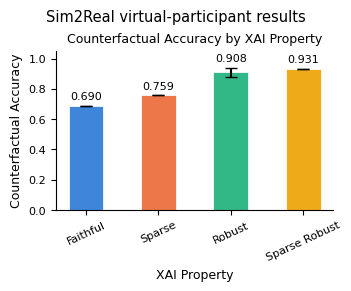

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

xaikitTest.plot_results_grid(
    ivs=["xai_property"],
    dvs=["counterfactual_accuracy"],
    phase="testing",
    title="Sim2Real virtual-participant results",
)

<details>
<summary>Click here to see the correct code</summary>

```python
xaikitTest.plot_results_grid(
    ivs=["xai_property"],
    dvs=["counterfactual_accuracy"],
    phase="testing",
    title="Sim2Real virtual-participant results",
)
```

</details>

### Step 4.3 Test pairwise condition differences

**Goal:**

Compare the four explanation properties against each other with a Holm
correction.

**Instruction:**

Run pairwise comparisons of `counterfactual_accuracy` across `xai_property` on
the testing rows, paired within participant, Holm-corrected.

Keep the caveat above in mind when you read the output.

<details>
<summary>Hint</summary>

*   `from src.statistical_analyst import pairwise_condition_tests`
*   `condition_cols=["xai_property"]`, `participant_col="participantId"`,
    `correction="holm"`.

</details>

In [ ]:
# YOUR CODE HERE

In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

from src.statistical_analyst import pairwise_condition_tests

pairwise_results = pairwise_condition_tests(
    testing_results,
    value_col="counterfactual_accuracy",
    condition_cols=["xai_property"],
    participant_col="participantId",
    correction="holm",
)
display(pairwise_results.table.round(4))

/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/wangzhuoyulucas/anaconda3/envs/xaik-api-dev/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/

,condition_a,condition_b,test,n_a,n_b,mean_a,mean_b,mean_difference,statistic,p_value,p_value_corrected,reject_null
0,xai_property=faithful,xai_property=sparse,welch_t,12,12,0.6897,0.7586,-0.0690,-1.456811e+15,0.0000,0.0000,True
1,xai_property=faithful,xai_property=robust,welch_t,12,12,0.6897,0.9080,-0.2184,-1.600600e+01,0.0000,0.0000,True
2,xai_property=faithful,xai_property=sparse_robust,welch_t,12,12,0.6897,0.9310,-0.2414,-7.210845e+15,0.0000,0.0000,True
3,xai_property=sparse,xai_property=robust,welch_t,12,12,0.7586,0.9080,-0.1494,-1.095150e+01,0.0000,0.0000,True
4,xai_property=sparse,xai_property=sparse_robust,welch_t,12,12,0.7586,0.9310,-0.1724,-5.150604e+15,0.0000,0.0000,True
5,xai_property=robust,xai_property=sparse_robust,welch_t,12,12,0.9080,0.9310,-0.0230,-1.684800e+00,0.1201,0.1201,False


<details>
<summary>Click here to see the correct code</summary>

```python
from src.statistical_analyst import pairwise_condition_tests

pairwise_results = pairwise_condition_tests(
    testing_results,
    value_col="counterfactual_accuracy",
    condition_cols=["xai_property"],
    participant_col="participantId",
    correction="holm",
)
display(pairwise_results.table.round(4))
```

</details>

### Step 4.4 Compare against the published human data

**Goal:**

See how well Sim2Real's calibrated strategies reproduce the real
participants they were fit to -- with the same plot and fit-stats table
the running server serves at `GET /api/human-comparison/sim2real`, not a
separately built report.

**Instruction:**

Call `server.pipeline.human_comparison_payload("sim2real")` -- the exact
function `server/app.py` calls behind that endpoint. It reads three files
already precomputed under `assets/` (`build_human_vs_model_plot_data.py`,
`build_human_vs_model_plots.py`, `build_human_vs_model_fit_stats.py`) and
returns the PNG, the panel data and the NLL/BIC fit-stats table together.
Display the PNG and turn `fit_stats` into a flat table.

<details>
<summary>Hint</summary>

```python
payload = pipeline.human_comparison_payload("sim2real")
```

*   `payload["plot_png"]` is a `data:image/png;base64,...` URI -- decode
    the part after the comma and pass the bytes to `IPython.display.Image`.
*   `payload["fit_stats"]["tables"][0]` has `models`, each with a `cells`
    dict keyed by facet (`Faithful`, `Sparse`, ...) -- flatten it into a
    `pd.DataFrame` with one row per `(model, facet)`.

</details>

In [ ]:
# YOUR CODE HERE

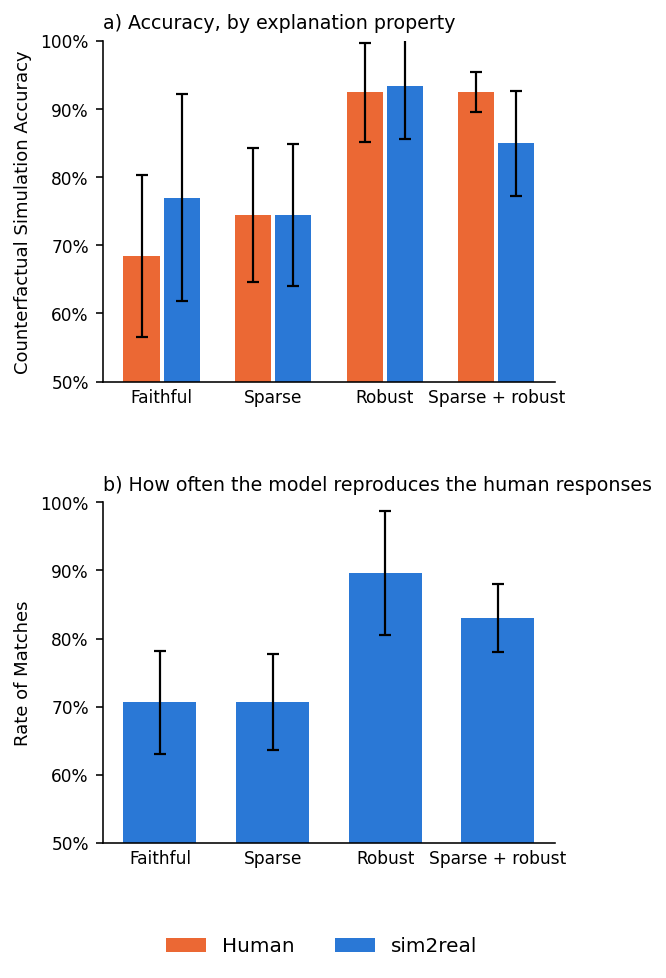

,model,facet,nll_mean,nll_sd,bic_mean,bic_sd,n
0,sim2real,Faithful,0.520,0.093,63.832,7.928,12
1,sim2real,Robust,0.207,0.221,45.693,12.802,11
2,sim2real,Sparse,0.535,0.101,55.464,12.087,12
3,sim2real,Sparse + robust,0.330,0.071,43.310,10.227,11
4,Decision Tree,Faithful,0.687,0.016,46.554,0.909,12
5,Decision Tree,Robust,0.849,0.094,55.962,5.439,11
6,Decision Tree,Sparse,0.877,0.085,57.583,4.924,12
7,Decision Tree,Sparse + robust,0.853,0.098,56.206,5.658,11
8,Logistic Regression,Faithful,1.199,0.613,76.301,35.532,12
9,Logistic Regression,Robust,0.890,0.647,58.351,37.542,11


In [ ]:
# Delete this cell after passing all tests. This is NOT for interviewees

payload = pipeline.human_comparison_payload("sim2real")
if payload is None:
    raise FileNotFoundError(
        "No precomputed human comparison for sim2real. Run "
        "assets/build_human_vs_model_plot_data.py, assets/build_human_vs_model_plots.py "
        "and assets/build_human_vs_model_fit_stats.py first."
    )

_, encoded = payload["plot_png"].split(",", 1)
display(Image(data=base64.b64decode(encoded)))

fit_stats_rows = [
    {"model": model["label"], "facet": facet, **cell}
    for table in payload["fit_stats"]["tables"]
    for model in table["models"]
    for facet, cell in model["cells"].items()
]
fit_stats_table = pd.DataFrame(fit_stats_rows)
display(fit_stats_table.round(3))

<details>
<summary>Click here to see the correct code</summary>

```python
payload = pipeline.human_comparison_payload("sim2real")
if payload is None:
    raise FileNotFoundError(
        "No precomputed human comparison for sim2real. Run "
        "assets/build_human_vs_model_plot_data.py, assets/build_human_vs_model_plots.py "
        "and assets/build_human_vs_model_fit_stats.py first."
    )

_, encoded = payload["plot_png"].split(",", 1)
display(Image(data=base64.b64decode(encoded)))

fit_stats_rows = [
    {"model": model["label"], "facet": facet, **cell}
    for table in payload["fit_stats"]["tables"]
    for model in table["models"]
    for facet, cell in model["cells"].items()
]
fit_stats_table = pd.DataFrame(fit_stats_rows)
display(fit_stats_table.round(3))
```

</details>

## What this notebook showed

*   A study can be run with **no dataset and no AI model** when the cognitive
    model carries its own published corpus.
*   The four conditions are **not simulated identically** -- strategy and lapse
    are chosen per condition to match measured human behaviour, and overriding
    `strategy` or `cognitive_params` silently discards that.
*   A cognitive model that is deterministic given its input produces **zero
    between-participant variance**, which changes what the participant-level
    statistics can tell you.